# A Colab-Scale Study of Speculative Decoding

## Practical Speed-Quality Frontiers on 1xA100

This notebook executes two complementary studies for LLM inference acceleration:
- **Study 1:** Transformers-assisted decoding (target+draft) with engineering ablations
- **Study 2:** vLLM + EAGLE-3 speculative decoding with production-style runtime settings

Primary outputs: latency, throughput, speedup, acceptance proxy, quality proxies, and paper-ready tables/plots.


## Execution Protocol
Run top-to-bottom and validate outputs at each checkpoint before continuing.

Environment assumptions:
- VS Code notebook connected to Google Colab kernel
- Runtime type: **A100 (High-RAM)**

Flow:
1. Study 1 (Cells 1-10)
2. Optional Study 1 extension (temperature ablation)
3. Study 2 (Cells A-E)


In [1]:
# Study 1 | Step 01 - Runtime Sanity Check
# Confirm Colab/GPU state and print core runtime metadata.

import os
import sys
import platform
import torch

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"COLAB_GPU env: {os.environ.get('COLAB_GPU')}")

if torch.cuda.is_available():
    print(f"GPU count: {torch.cuda.device_count()}")
    print(f"GPU[0]: {torch.cuda.get_device_name(0)}")
    print(f"Compute capability: {torch.cuda.get_device_capability(0)}")
else:
    print("WARNING: CUDA is not available.")

if "COLAB_GPU" not in os.environ:
    print("WARNING: This kernel does not look like Colab runtime.")


Python: 3.12.12
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
PyTorch: 2.8.0+cu128
CUDA available: True
COLAB_GPU env: 1
GPU count: 1
GPU[0]: NVIDIA A100-SXM4-80GB
Compute capability: (8, 0)


In [22]:
# Study 1 | Step 02 - Install Dependencies
# Install/pin package versions for reproducible Colab execution.

import sys
import shlex
import subprocess
from importlib.metadata import version, PackageNotFoundError

packages = [
    "transformers>=4.53.0,<5.0.0",
    "datasets>=2.19.0,<5.0.0",
    "evaluate>=0.4.0,<1.0.0",
    "pandas==2.2.2",
    "matplotlib==3.10.0",
    "seaborn>=0.13.2,<0.14.0",
    "accelerate>=0.34.0",
    "sentencepiece>=0.2.0",
]

cmd = [sys.executable, "-m", "pip", "install", "-U", "--upgrade-strategy", "only-if-needed", *packages]
print("Running:", " ".join(shlex.quote(x) for x in cmd))
res = subprocess.run(cmd, capture_output=True, text=True)

if res.stdout:
    print("\n[pip stdout - tail]\n")
    print(res.stdout[-6000:])
if res.stderr:
    print("\n[pip stderr - tail]\n")
    print(res.stderr[-6000:])

if res.returncode != 0:
    raise RuntimeError(f"Dependency install failed with exit code {res.returncode}")

print("\nInstalled package versions (from metadata):")
for pkg in ["transformers", "datasets", "evaluate", "pandas", "matplotlib", "seaborn", "accelerate", "sentencepiece"]:
    try:
        print(f"- {pkg}: {version(pkg)}")
    except PackageNotFoundError:
        print(f"- {pkg}: NOT FOUND")

print("\nIf versions changed in this cell, restart kernel before continuing to Cell 3.")



Running: /usr/bin/python3 -m pip install -U --upgrade-strategy only-if-needed 'transformers>=4.53.0,<5.0.0' 'datasets>=2.19.0,<5.0.0' 'evaluate>=0.4.0,<1.0.0' pandas==2.2.2 matplotlib==3.10.0 'seaborn>=0.13.2,<0.14.0' 'accelerate>=0.34.0' 'sentencepiece>=0.2.0'

[pip stdout - tail]

isfied: idna in /usr/local/lib/python3.12/dist-packages (from httpx<1.0.0->datasets<5.0.0,>=2.19.0) (3.11)


Installed package versions (from metadata):
- transformers: 4.57.6
- datasets: 4.6.1
- evaluate: 0.4.6
- pandas: 2.2.2
- matplotlib: 3.10.0
- seaborn: 0.13.2
- accelerate: 1.12.0
- sentencepiece: 0.2.1

If versions changed in this cell, restart kernel before continuing to Cell 3.


In [2]:
# Study 1 | Step 03 - Imports and Global Config
# Load libraries, set deterministic seeds, and define experiment config.

import gc
import re
import time
import json
import random
import os
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, __version__ as transformers_version

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.set_grad_enabled(False)

CONFIG = {
    "target_model_id": "Qwen/Qwen2.5-7B-Instruct",
    "draft_models": {
        "close_match": "Qwen/Qwen2.5-0.5B-Instruct",
        "mismatch": "Qwen/Qwen2.5-0.5B",
    },
    "max_new_tokens": 128,
    "block_sizes": [8, 16],
    "assistant_confidence_threshold": 0.4,
    "dataset_size": 24,
    "acceptance_eval_size": 12,
    "results_dir": "./spec_decoding_results_phase2",
}



# Phase-2: prefer Google Drive for artifacts (with safe fallback)
if "google.colab" in sys.modules:
    try:
        from google.colab import drive  # type: ignore
        if not os.path.ismount("/content/drive"):
            drive.mount("/content/drive", force_remount=False)
        CONFIG["results_dir"] = "/content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2"
    except Exception as e:
        print(f"Google Drive mount skipped/fallback: {e}")
        CONFIG["results_dir"] = "./spec_decoding_results_phase2"
else:
    CONFIG["results_dir"] = "./spec_decoding_results_phase2"

print(f"Transformers version: {transformers_version}")
print(json.dumps(CONFIG, indent=2))



Transformers version: 4.57.6
{
  "target_model_id": "Qwen/Qwen2.5-7B-Instruct",
  "draft_models": {
    "close_match": "Qwen/Qwen2.5-0.5B-Instruct",
    "mismatch": "Qwen/Qwen2.5-0.5B"
  },
  "max_new_tokens": 128,
  "block_sizes": [
    8,
    16
  ],
  "assistant_confidence_threshold": 0.4,
  "dataset_size": 24,
  "acceptance_eval_size": 12,
  "results_dir": "/content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2"
}


In [14]:
# Study 1 | Step 04 - Load Target and Draft Assets
# Initialize tokenizer/model objects used by Study 1 runs.

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32

print(f"Using device: {DEVICE}")
print(f"Target dtype: {DTYPE}")

TARGET_MODEL_ID = CONFIG["target_model_id"]
DRAFT_MODEL_IDS = CONFIG["draft_models"]

tokenizer = AutoTokenizer.from_pretrained(TARGET_MODEL_ID, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

target_model = AutoModelForCausalLM.from_pretrained(
    TARGET_MODEL_ID,
    torch_dtype=DTYPE,
    device_map="auto",
    low_cpu_mem_usage=True,
)
target_model.eval()
target_model.generation_config.pad_token_id = tokenizer.pad_token_id

# Avoid warnings for greedy decoding when model config has sampling defaults
for _k in ["temperature", "top_p", "top_k"]:
    try:
        setattr(target_model.generation_config, _k, None)
    except Exception:
        pass

TARGET_DEVICE = next(target_model.parameters()).device
print(f"Target model loaded on: {TARGET_DEVICE}")

current_draft_model_id = None
draft_model = None
draft_tokenizer = None

def load_draft_model(model_id: str):
    global draft_model, draft_tokenizer, current_draft_model_id
    if current_draft_model_id == model_id and draft_model is not None and draft_tokenizer is not None:
        print(f"Draft already loaded: {model_id}")
        return draft_model

    if draft_model is not None:
        del draft_model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(f"Loading draft model: {model_id}")
    draft_tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)
    if draft_tokenizer.pad_token is None:
        draft_tokenizer.pad_token = draft_tokenizer.eos_token

    draft_model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=DTYPE,
        device_map="auto",
        low_cpu_mem_usage=True,
    )
    draft_model.eval()
    draft_model.generation_config.pad_token_id = draft_tokenizer.pad_token_id

    # Keep draft generation config aligned for greedy decoding
    for _k in ["temperature", "top_p", "top_k"]:
        try:
            setattr(draft_model.generation_config, _k, None)
        except Exception:
            pass

    current_draft_model_id = model_id
    return draft_model


Using device: cuda
Target dtype: torch.bfloat16


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Target model loaded on: cuda:0


In [15]:
# Study 1 | Step 05 - Benchmark Utility Functions
# Define generation, quality, and acceptance helper utilities.

def normalize_text(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def exact_match(pred: str, gold_answers):
    p = normalize_text(pred)
    return float(any(p == normalize_text(g) for g in gold_answers if isinstance(g, str)))


def qa_f1_single(pred: str, gold: str) -> float:
    p_toks = normalize_text(pred).split()
    g_toks = normalize_text(gold).split()
    if len(p_toks) == 0 and len(g_toks) == 0:
        return 1.0
    if len(p_toks) == 0 or len(g_toks) == 0:
        return 0.0
    common = {}
    for t in p_toks:
        common[t] = common.get(t, 0) + 1
    overlap = 0
    for t in g_toks:
        c = common.get(t, 0)
        if c > 0:
            overlap += 1
            common[t] = c - 1
    if overlap == 0:
        return 0.0
    precision = overlap / len(p_toks)
    recall = overlap / len(g_toks)
    return 2 * precision * recall / (precision + recall)


def qa_best_f1(pred: str, gold_answers) -> float:
    scores = [qa_f1_single(pred, g) for g in gold_answers if isinstance(g, str)]
    return float(max(scores)) if scores else 0.0


@torch.inference_mode()
def timed_generate(
    prompt: str,
    max_new_tokens: int,
    do_sample: bool = False,
    temperature: float = 1.0,
    assistant_model=None,
    assistant_tokenizer=None,
    num_assistant_tokens: int = 16,
    assistant_confidence_threshold: float = 0.4,
):
    enc = tokenizer(prompt, return_tensors="pt")
    enc = {k: v.to(TARGET_DEVICE) for k, v in enc.items()}

    gen_kwargs = {
        "max_new_tokens": max_new_tokens,
        "do_sample": do_sample,
        "pad_token_id": tokenizer.pad_token_id,
        "eos_token_id": tokenizer.eos_token_id,
        "return_dict_in_generate": True,
        "use_cache": True,
    }
    if do_sample:
        gen_kwargs.update({"temperature": temperature, "top_p": 0.95})

    if assistant_model is not None:
        gen_kwargs.update(
            {
                "assistant_model": assistant_model,
                "num_assistant_tokens": int(num_assistant_tokens),
                "num_assistant_tokens_schedule": "constant",
                "assistant_confidence_threshold": float(assistant_confidence_threshold),
                # Required by universal assisted decoding when tokenizers differ
                "tokenizer": tokenizer,
                "assistant_tokenizer": assistant_tokenizer if assistant_tokenizer is not None else tokenizer,
            }
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    out = target_model.generate(**enc, **gen_kwargs)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0

    seq = out.sequences[0]
    input_len = enc["input_ids"].shape[1]
    new_ids = seq[input_len:].detach().cpu()
    new_tokens = int(new_ids.numel())
    tps = float(new_tokens / elapsed) if elapsed > 0 else 0.0
    text = tokenizer.decode(new_ids, skip_special_tokens=True)

    return {
        "text": text,
        "new_ids": new_ids,
        "new_tokens": new_tokens,
        "latency_s": float(elapsed),
        "tps": tps,
    }


def run_suite(
    prompts,
    max_new_tokens,
    label,
    assistant_model=None,
    assistant_tokenizer=None,
    num_assistant_tokens=16,
    assistant_confidence_threshold=0.4,
    do_sample=False,
    temperature=1.0,
):
    rows = []
    print(f"\nRunning suite: {label} | prompts={len(prompts)}")

    if len(prompts) > 0:
        _ = timed_generate(
            prompt=prompts[0],
            max_new_tokens=min(16, max_new_tokens),
            do_sample=do_sample,
            temperature=temperature,
            assistant_model=assistant_model,
            assistant_tokenizer=assistant_tokenizer,
            num_assistant_tokens=num_assistant_tokens,
            assistant_confidence_threshold=assistant_confidence_threshold,
        )
        print("  Warmup complete (excluded from metrics).")

    for i, prompt in enumerate(prompts, start=1):
        result = timed_generate(
            prompt=prompt,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            temperature=temperature,
            assistant_model=assistant_model,
            assistant_tokenizer=assistant_tokenizer,
            num_assistant_tokens=num_assistant_tokens,
            assistant_confidence_threshold=assistant_confidence_threshold,
        )
        rows.append({"idx": i, "prompt": prompt, **result})
        if i == 1 or i % 5 == 0 or i == len(prompts):
            print(
                f"  {i:>2}/{len(prompts)} | latency={result['latency_s']:.3f}s | "
                f"new_tokens={result['new_tokens']} | tps={result['tps']:.2f}"
            )

    df = pd.DataFrame(rows)
    summary = {
        "label": label,
        "n": int(len(df)),
        "mean_latency_s": float(df["latency_s"].mean()),
        "p50_latency_s": float(df["latency_s"].median()),
        "mean_tps": float(df["tps"].mean()),
        "total_tokens": int(df["new_tokens"].sum()),
        "total_time_s": float(df["latency_s"].sum()),
        "global_tps": float(df["new_tokens"].sum() / max(df["latency_s"].sum(), 1e-9)),
    }
    print(f"Summary [{label}]: {json.dumps(summary, indent=2)}")
    return df, summary


def qa_quality_metrics(predictions, references):
    em_scores = [exact_match(p, r) for p, r in zip(predictions, references)]
    f1_scores = [qa_best_f1(p, r) for p, r in zip(predictions, references)]
    return {
        "em_mean": float(np.mean(em_scores)) if em_scores else 0.0,
        "f1_mean": float(np.mean(f1_scores)) if f1_scores else 0.0,
        "em_per_example": em_scores,
        "f1_per_example": f1_scores,
    }


@torch.inference_mode()
def estimate_acceptance_rate_for_prompt(prompt, target_new_ids, draft_model, block_size):
    # Greedy acceptance-rate proxy based on baseline target continuation tokens.
    prefix = tokenizer(prompt, return_tensors="pt")["input_ids"].to(TARGET_DEVICE)
    ref = target_new_ids.to(TARGET_DEVICE)

    pos = 0
    accepted = 0
    proposed = 0

    while pos < ref.shape[0]:
        step_k = min(int(block_size), int(ref.shape[0] - pos))

        draft_out = draft_model.generate(
            input_ids=prefix,
            max_new_tokens=step_k,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            use_cache=True,
        )
        cand = draft_out[0, prefix.shape[1]:prefix.shape[1] + step_k]
        cand_len = int(cand.shape[0])
        proposed += cand_len

        ref_slice = ref[pos:pos + cand_len]
        match = 0
        for j in range(cand_len):
            if int(cand[j]) == int(ref_slice[j]):
                match += 1
            else:
                break

        accepted += match

        if match < cand_len:
            advance = max(1, match + 1)
        else:
            advance = max(1, match)

        advance = min(advance, int(ref.shape[0] - pos))
        prefix = torch.cat([prefix, ref[pos:pos + advance].unsqueeze(0)], dim=1)
        pos += advance

    if proposed == 0:
        return 0.0
    return float(accepted / proposed)


def estimate_dataset_acceptance(prompts, baseline_new_ids, draft_model, block_size, max_items=12):
    rates = []
    eval_n = min(max_items, len(prompts), len(baseline_new_ids))
    for i in range(eval_n):
        rate = estimate_acceptance_rate_for_prompt(
            prompts[i], baseline_new_ids[i], draft_model, block_size
        )
        rates.append(rate)
    return float(np.mean(rates)) if rates else 0.0, rates



In [16]:
# Study 1 | Step 06 - Build Benchmark Prompt Sets
# Construct short/long/QA prompt subsets from SQuAD.

raw = load_dataset("squad", split=f"validation[:{CONFIG['dataset_size']}]" )

def trim_context_by_chars(text, max_chars=1400):
    return text[:max_chars]

qa_examples = []
for ex in raw:
    context = trim_context_by_chars(ex["context"], max_chars=1400)
    question = ex["question"].strip()
    refs = ex["answers"]["text"]

    long_prompt = (
        "Return ONLY the exact answer span from the context. No explanation.\n"
        f"Context:\n{context}\n\n"
        f"Question: {question}\n"
        "Answer:"
    )
    short_prompt = (
        "Return ONLY a short answer phrase. No explanation.\n"
        f"Question: {question}\n"
        "Answer:"
    )

    qa_examples.append(
        {
            "short_prompt": short_prompt,
            "long_prompt": long_prompt,
            "qa_prompt": long_prompt,
            "references": refs,
        }
    )

short_prompts = [x["short_prompt"] for x in qa_examples]
long_prompts = [x["long_prompt"] for x in qa_examples]
qa_prompts = [x["qa_prompt"] for x in qa_examples]
qa_references = [x["references"] for x in qa_examples]

print(f"Prepared prompts: {len(qa_examples)}")
print("Short prompt sample:")
print(short_prompts[0][:300])
print("\nLong prompt sample:")
print(long_prompts[0][:300])


Prepared prompts: 24
Short prompt sample:
Return ONLY a short answer phrase. No explanation.
Question: Which NFL team represented the AFC at Super Bowl 50?
Answer:

Long prompt sample:
Return ONLY the exact answer span from the context. No explanation.
Context:
Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos defeated the National Football 


In [17]:
# Study 1 | Step 07 - Baseline Decode Runs
# Run target-only baseline to establish reference latency/throughput.

baseline_short_df, baseline_short_summary = run_suite(
    prompts=short_prompts,
    max_new_tokens=CONFIG["max_new_tokens"],
    label="baseline_short",
)

baseline_long_df, baseline_long_summary = run_suite(
    prompts=long_prompts,
    max_new_tokens=CONFIG["max_new_tokens"],
    label="baseline_long",
)

baseline_qa_df, baseline_qa_summary = run_suite(
    prompts=qa_prompts,
    max_new_tokens=CONFIG["max_new_tokens"],
    label="baseline_qa",
)

baseline_quality = qa_quality_metrics(
    baseline_qa_df["text"].tolist(),
    qa_references,
)
baseline_qa_em = baseline_quality["em_mean"]
baseline_qa_f1 = baseline_quality["f1_mean"]

print(f"\nBaseline QA Exact Match: {baseline_qa_em:.4f}")
print(f"Baseline QA F1: {baseline_qa_f1:.4f}")



Running suite: baseline_short | prompts=24
  Warmup complete (excluded from metrics).
   1/24 | latency=4.024s | new_tokens=128 | tps=31.81
   5/24 | latency=4.004s | new_tokens=128 | tps=31.97
  10/24 | latency=4.014s | new_tokens=128 | tps=31.89
  15/24 | latency=4.025s | new_tokens=128 | tps=31.80
  20/24 | latency=3.999s | new_tokens=128 | tps=32.01
  24/24 | latency=3.981s | new_tokens=128 | tps=32.15
Summary [baseline_short]: {
  "label": "baseline_short",
  "n": 24,
  "mean_latency_s": 4.017306997166732,
  "p50_latency_s": 4.01851161850027,
  "mean_tps": 31.86345677983177,
  "total_tokens": 3072,
  "total_time_s": 96.41536793200157,
  "global_tps": 31.86214050613358
}

Running suite: baseline_long | prompts=24
  Warmup complete (excluded from metrics).
   1/24 | latency=4.045s | new_tokens=128 | tps=31.64
   5/24 | latency=4.057s | new_tokens=128 | tps=31.55
  10/24 | latency=4.072s | new_tokens=128 | tps=31.43
  15/24 | latency=4.099s | new_tokens=128 | tps=31.23
  20/24 | lat

In [18]:
# Study 1 | Step 08 - Assisted-Decoding Ablations
# Evaluate block size and draft-target mismatch configurations.

experiment_rows = []

configs = []
for b in CONFIG["block_sizes"]:
    configs.append(
        {
            "name": f"close_match_b{b}",
            "draft_key": "close_match",
            "block_size": int(b),
            "do_sample": False,
            "temperature": 1.0,
        }
    )

configs.append(
    {
        "name": "mismatch_b16",
        "draft_key": "mismatch",
        "block_size": 16,
        "do_sample": False,
        "temperature": 1.0,
    }
)

for cfg in configs:
    print("\n" + "=" * 90)
    print(f"Running config: {cfg['name']}")

    dm = load_draft_model(DRAFT_MODEL_IDS[cfg["draft_key"]])
    dtok = draft_tokenizer

    spec_short_df, spec_short_summary = run_suite(
        prompts=short_prompts,
        max_new_tokens=CONFIG["max_new_tokens"],
        label=f"{cfg['name']}_short",
        assistant_model=dm,
        assistant_tokenizer=dtok,
        num_assistant_tokens=cfg["block_size"],
        assistant_confidence_threshold=CONFIG["assistant_confidence_threshold"],
        do_sample=cfg["do_sample"],
        temperature=cfg["temperature"],
    )

    spec_long_df, spec_long_summary = run_suite(
        prompts=long_prompts,
        max_new_tokens=CONFIG["max_new_tokens"],
        label=f"{cfg['name']}_long",
        assistant_model=dm,
        assistant_tokenizer=dtok,
        num_assistant_tokens=cfg["block_size"],
        assistant_confidence_threshold=CONFIG["assistant_confidence_threshold"],
        do_sample=cfg["do_sample"],
        temperature=cfg["temperature"],
    )

    spec_qa_df, spec_qa_summary = run_suite(
        prompts=qa_prompts,
        max_new_tokens=CONFIG["max_new_tokens"],
        label=f"{cfg['name']}_qa",
        assistant_model=dm,
        assistant_tokenizer=dtok,
        num_assistant_tokens=cfg["block_size"],
        assistant_confidence_threshold=CONFIG["assistant_confidence_threshold"],
        do_sample=cfg["do_sample"],
        temperature=cfg["temperature"],
    )

    quality = qa_quality_metrics(
        spec_qa_df["text"].tolist(),
        qa_references,
    )
    qa_em = quality["em_mean"]
    qa_f1 = quality["f1_mean"]

    em_vs_baseline = float(
        np.mean(
            [
                normalize_text(a) == normalize_text(b)
                for a, b in zip(spec_qa_df["text"].tolist(), baseline_qa_df["text"].tolist())
            ]
        )
    )

    acceptance_mean, _ = estimate_dataset_acceptance(
        prompts=qa_prompts,
        baseline_new_ids=baseline_qa_df["new_ids"].tolist(),
        draft_model=dm,
        block_size=cfg["block_size"],
        max_items=CONFIG["acceptance_eval_size"],
    )

    speedup_short = baseline_short_summary["total_time_s"] / spec_short_summary["total_time_s"]
    speedup_long = baseline_long_summary["total_time_s"] / spec_long_summary["total_time_s"]
    speedup_qa = baseline_qa_summary["total_time_s"] / spec_qa_summary["total_time_s"]

    experiment_rows.append(
        {
            "config": cfg["name"],
            "draft_key": cfg["draft_key"],
            "draft_model_id": DRAFT_MODEL_IDS[cfg["draft_key"]],
            "block_size": cfg["block_size"],
            "do_sample": cfg["do_sample"],
            "temperature": cfg["temperature"],
            "speedup_short": float(speedup_short),
            "speedup_long": float(speedup_long),
            "speedup_qa": float(speedup_qa),
            "latency_short_s": float(spec_short_summary["mean_latency_s"]),
            "latency_long_s": float(spec_long_summary["mean_latency_s"]),
            "tps_short": float(spec_short_summary["mean_tps"]),
            "tps_long": float(spec_long_summary["mean_tps"]),
            "qa_em": float(qa_em),
            "qa_f1": float(qa_f1),
            "qa_em_vs_baseline": em_vs_baseline,
            "acceptance_rate": float(acceptance_mean),
        }
    )

results_df = pd.DataFrame(experiment_rows)
results_df = results_df.sort_values(by="speedup_qa", ascending=False).reset_index(drop=True)

print("\nTop configurations by QA speedup:")
display(results_df.head(10))




Running config: close_match_b8
Loading draft model: Qwen/Qwen2.5-0.5B-Instruct

Running suite: close_match_b8_short | prompts=24
  Warmup complete (excluded from metrics).
   1/24 | latency=14.031s | new_tokens=128 | tps=9.12
   5/24 | latency=15.398s | new_tokens=128 | tps=8.31
  10/24 | latency=10.373s | new_tokens=128 | tps=12.34
  15/24 | latency=7.958s | new_tokens=128 | tps=16.08
  20/24 | latency=32.629s | new_tokens=128 | tps=3.92
  24/24 | latency=8.241s | new_tokens=128 | tps=15.53
Summary [close_match_b8_short]: {
  "label": "close_match_b8_short",
  "n": 24,
  "mean_latency_s": 13.694667947416633,
  "p50_latency_s": 12.931013879000147,
  "mean_tps": 11.03951256838391,
  "total_tokens": 3072,
  "total_time_s": 328.6720307379992,
  "global_tps": 9.346703438994004
}

Running suite: close_match_b8_long | prompts=24
  Warmup complete (excluded from metrics).
   1/24 | latency=16.409s | new_tokens=128 | tps=7.80
   5/24 | latency=10.015s | new_tokens=128 | tps=12.78
  10/24 | la

,config,draft_key,draft_model_id,block_size,do_sample,temperature,speedup_short,speedup_long,speedup_qa,latency_short_s,latency_long_s,tps_short,tps_long,qa_em,qa_f1,qa_em_vs_baseline,acceptance_rate
0,mismatch_b16,mismatch,Qwen/Qwen2.5-0.5B,16,False,1.0,0.251255,0.356633,0.354550,15.988941,11.415447,9.943368,12.095883,0.0,0.058579,0.166667,0.169218
1,close_match_b16,close_match,Qwen/Qwen2.5-0.5B-Instruct,16,False,1.0,0.292196,0.313645,0.312382,13.748656,12.980058,10.986117,10.525802,0.0,0.059029,0.250000,0.163551
2,close_match_b8,close_match,Qwen/Qwen2.5-0.5B-Instruct,8,False,1.0,0.293348,0.314503,0.310430,13.694668,12.944659,11.039513,10.563105,0.0,0.059029,0.250000,0.280379


/tmp/ipython-input-1351/3195014836.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


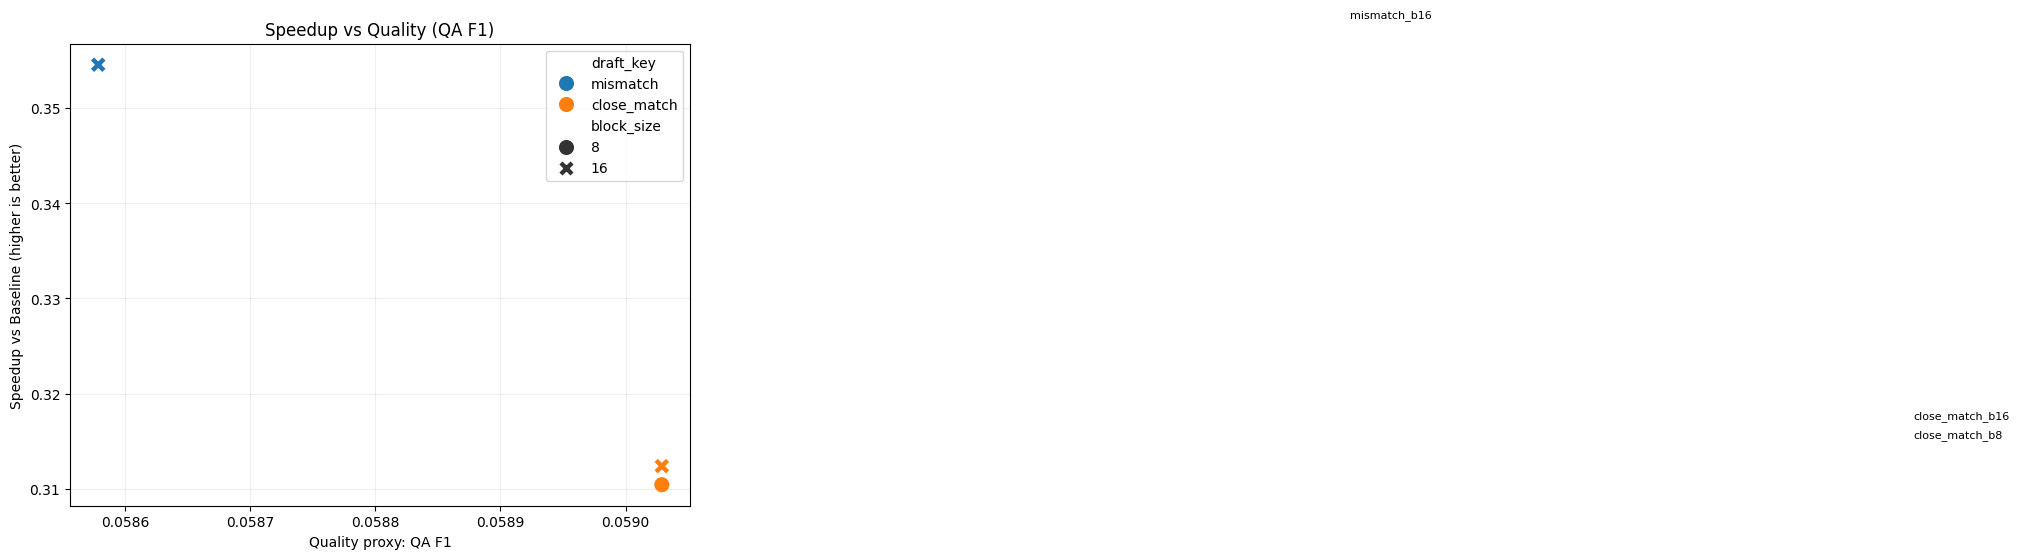

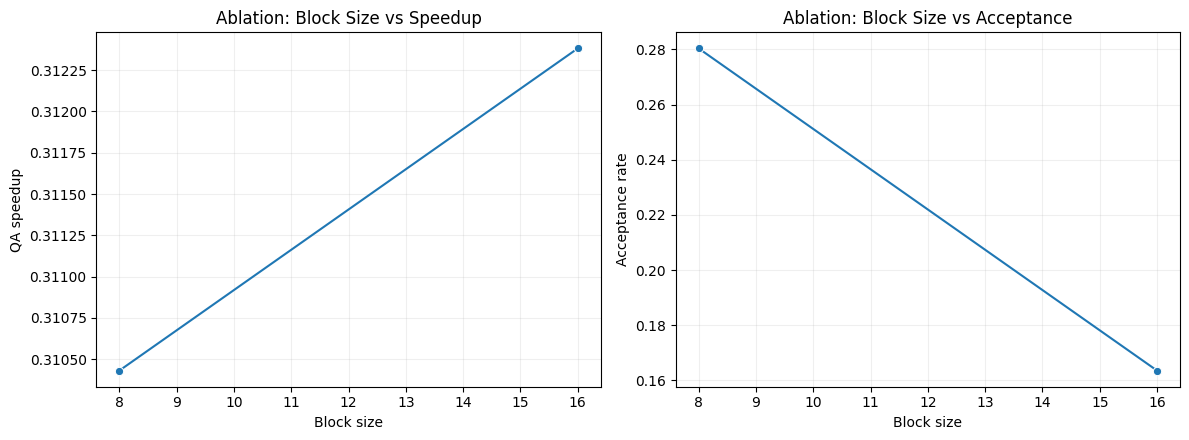

Latency table (short vs long prompts):


,config,latency_short_s,latency_long_s,speedup_short,speedup_long
0,baseline,4.017307,4.071129,1.000000,1.000000
1,mismatch_b16,15.988941,11.415447,0.251255,0.356633
2,close_match_b8,13.694668,12.944659,0.293348,0.314503
3,close_match_b16,13.748656,12.980058,0.292196,0.313645


In [19]:
# Study 1 | Step 09 - Plotting and Summary Tables
# Build speed-quality plot, ablation figure, and latency summary table.

import os
os.makedirs(CONFIG["results_dir"], exist_ok=True)

plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    data=results_df,
    x="qa_f1",
    y="speedup_qa",
    hue="draft_key",
    style="block_size",
    s=140,
)
for _, r in results_df.iterrows():
    ax.text(r["qa_f1"] + 0.001, r["speedup_qa"] + 0.005, r["config"], fontsize=8)
ax.set_title("Speedup vs Quality (QA F1)")
ax.set_xlabel("Quality proxy: QA F1")
ax.set_ylabel("Speedup vs Baseline (higher is better)")
ax.grid(alpha=0.2)
plt.tight_layout()
main_fig_path = os.path.join(CONFIG["results_dir"], "speedup_vs_quality.png")
plt.savefig(main_fig_path, dpi=180)
plt.show()

block_df = results_df[results_df["draft_key"] == "close_match"].sort_values("block_size")
if len(block_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    sns.lineplot(data=block_df, x="block_size", y="speedup_qa", marker="o", ax=axes[0])
    axes[0].set_title("Ablation: Block Size vs Speedup")
    axes[0].set_xlabel("Block size")
    axes[0].set_ylabel("QA speedup")
    axes[0].grid(alpha=0.2)

    sns.lineplot(data=block_df, x="block_size", y="acceptance_rate", marker="o", ax=axes[1])
    axes[1].set_title("Ablation: Block Size vs Acceptance")
    axes[1].set_xlabel("Block size")
    axes[1].set_ylabel("Acceptance rate")
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    ablation_fig_path = os.path.join(CONFIG["results_dir"], "ablation_block_size.png")
    plt.savefig(ablation_fig_path, dpi=180)
    plt.show()

latency_rows = [
    {
        "config": "baseline",
        "latency_short_s": baseline_short_summary["mean_latency_s"],
        "latency_long_s": baseline_long_summary["mean_latency_s"],
        "speedup_short": 1.0,
        "speedup_long": 1.0,
    }
]
for _, r in results_df.iterrows():
    latency_rows.append(
        {
            "config": r["config"],
            "latency_short_s": r["latency_short_s"],
            "latency_long_s": r["latency_long_s"],
            "speedup_short": r["speedup_short"],
            "speedup_long": r["speedup_long"],
        }
    )

latency_table_df = pd.DataFrame(latency_rows)
latency_table_df = latency_table_df.sort_values(by="speedup_long", ascending=False).reset_index(drop=True)
print("Latency table (short vs long prompts):")
display(latency_table_df)


In [20]:
# Study 1 | Step 10 - Persist Artifacts
# Save tables/plots/metrics needed for manuscript integration.

import os
os.makedirs(CONFIG["results_dir"], exist_ok=True)

results_csv = os.path.join(CONFIG["results_dir"], "spec_decoding_results.csv")
results_json = os.path.join(CONFIG["results_dir"], "spec_decoding_results.json")
latency_csv = os.path.join(CONFIG["results_dir"], "latency_table.csv")

results_df.to_csv(results_csv, index=False)
results_df.to_json(results_json, orient="records", indent=2)
latency_table_df.to_csv(latency_csv, index=False)

print("Saved:")
print(f"- {results_csv}")
print(f"- {results_json}")
print(f"- {latency_csv}")
print(f"- {os.path.join(CONFIG['results_dir'], 'speedup_vs_quality.png')}")
print(f"- {os.path.join(CONFIG['results_dir'], 'ablation_block_size.png')}")


Saved:
- /content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2/spec_decoding_results.csv
- /content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2/spec_decoding_results.json
- /content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2/latency_table.csv
- /content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2/speedup_vs_quality.png
- /content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2/ablation_block_size.png


## Study 1 Checkpoint
Study 1 should have produced:
- Baseline vs assisted-decoding comparison tables
- Speedup-quality and ablation plots
- Exported artifacts for manuscript integration


## Optional Study 1 Extension
Use this only for additional sampling analysis (`do_sample=True`, temperature sweep).

Keep optional in core runs because it increases runtime and introduces stochastic variance.


## Study 2: vLLM + EAGLE-3 Benchmark Path
This section evaluates a production-oriented serving stack on 1xA100.

Practical intent:
- compare against baseline vLLM decode
- measure speculative-token ablations (`n=3,5`)
- export paper-ready Study 2 artifacts


In [25]:
# Study 2 | Step A - Install vLLM Stack
# Install vLLM-specific dependencies for Study 2.

import sys
import shlex
import subprocess
import importlib.util

if importlib.util.find_spec("vllm") is None:
    cmd = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-U",
        "vllm==0.11.0",
        "rouge-score",
    ]
    print("Running:", " ".join(shlex.quote(x) for x in cmd))
    res = subprocess.run(cmd, capture_output=True, text=True)
    print("\n[pip stdout - tail]\n")
    print(res.stdout[-6000:])
    if res.stderr:
        print("\n[pip stderr - tail]\n")
        print(res.stderr[-6000:])
    if res.returncode != 0:
        raise RuntimeError(f"vLLM install failed with code {res.returncode}")
    print("\nIf this was a fresh vLLM install, restart kernel before running Phase-3 Cell B.")
else:
    import vllm
    print("vLLM already installed:", vllm.__version__)


Running: /usr/bin/python3 -m pip install -U vllm==0.11.0 rouge-score

[pip stdout - tail]

312-manylinux2014_x86_64.whl (73.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.0/388.0 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.4/285.4 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.9/224.9 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 114.4 MB/s eta 0:00

In [13]:
# Study 2 | Step B - Configure Inputs and Runtime
# Define Study 2 config and prepare benchmark inputs.

import os
import gc
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

os.environ["VLLM_USE_V1"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from vllm import LLM, SamplingParams, __version__ as vllm_version

PHASE3 = {
    "target_model_id": "Qwen/Qwen3-8B",
    "speculator_model_id": "RedHatAI/Qwen3-8B-speculator.eagle3",
    "num_speculative_tokens_grid": [3, 5],
    "max_new_tokens": 128,
    "temperature": 0.6,
    "top_p": 0.95,
    "top_k": 20,
    "eval_per_dataset": 12,
    "max_prompt_chars": 6500,
    "max_model_len": 4096,
    "gpu_memory_utilization": 0.55,  # safe default; Cell D auto-adjusts based on free VRAM
}

phase3_results_dir = Path(CONFIG["results_dir"]) / "phase3_vllm"
phase3_results_dir.mkdir(parents=True, exist_ok=True)

print("vLLM version:", vllm_version)
print(json.dumps(PHASE3, indent=2))
print("phase3_results_dir:", str(phase3_results_dir))

sum_url = "https://huggingface.co/datasets/RedHatAI/speculator_benchmarks/resolve/main/summarization.jsonl"
math_url = "https://huggingface.co/datasets/RedHatAI/speculator_benchmarks/resolve/main/math_reasoning.jsonl"

sum_ds = load_dataset("json", data_files={"train": sum_url}, split=f"train[:{PHASE3['eval_per_dataset']}]")
math_ds = load_dataset("json", data_files={"train": math_url}, split=f"train[:{PHASE3['eval_per_dataset']}]")

phase3_inputs = []

def _pick_reference(ex):
    ref = ex.get("reference", [])
    if isinstance(ref, list) and len(ref) > 0:
        return str(ref[0])
    return ""

for ex in sum_ds:
    prompt = str(ex["turns"][0])[: PHASE3["max_prompt_chars"]]
    phase3_inputs.append(
        {
            "prompt": prompt,
            "reference": _pick_reference(ex),
            "category": "summarization",
        }
    )

for ex in math_ds:
    prompt = str(ex["turns"][0])[: PHASE3["max_prompt_chars"]]
    phase3_inputs.append(
        {
            "prompt": prompt,
            "reference": _pick_reference(ex),
            "category": "math_reasoning",
        }
    )

phase3_input_df = pd.DataFrame(phase3_inputs).reset_index(drop=True)
phase3_input_df["prompt_len_chars"] = phase3_input_df["prompt"].str.len()

print("Prepared phase3 prompts:", len(phase3_input_df))
print(phase3_input_df.groupby("category")["prompt"].count())
print("Prompt length stats (chars):")
print(phase3_input_df["prompt_len_chars"].describe())



vLLM version: 0.11.0
{
  "target_model_id": "Qwen/Qwen3-8B",
  "speculator_model_id": "RedHatAI/Qwen3-8B-speculator.eagle3",
  "num_speculative_tokens_grid": [
    3,
    5
  ],
  "max_new_tokens": 128,
  "temperature": 0.6,
  "top_p": 0.95,
  "top_k": 20,
  "eval_per_dataset": 12,
  "max_prompt_chars": 6500,
  "max_model_len": 4096,
  "gpu_memory_utilization": 0.55
}
phase3_results_dir: /content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2/phase3_vllm
Prepared phase3 prompts: 24
category
math_reasoning    12
summarization     12
Name: prompt, dtype: int64
Prompt length stats (chars):
count      24.000000
mean     1596.208333
std      1571.330646
min       146.000000
25%       196.000000
50%       880.000000
75%      2928.000000
max      5157.000000
Name: prompt_len_chars, dtype: float64


In [4]:
# Study 2 | Step C - Helper Functions
# Define Study 2 evaluation and aggregation helpers.


def _normalize_text_local(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def _qa_f1_local(pred: str, ref: str) -> float:
    p = _normalize_text_local(pred).split()
    r = _normalize_text_local(ref).split()
    if len(p) == 0 and len(r) == 0:
        return 1.0
    if len(p) == 0 or len(r) == 0:
        return 0.0

    common = {}
    for t in p:
        common[t] = common.get(t, 0) + 1

    overlap = 0
    for t in r:
        c = common.get(t, 0)
        if c > 0:
            overlap += 1
            common[t] = c - 1

    if overlap == 0:
        return 0.0

    precision = overlap / len(p)
    recall = overlap / len(r)
    return 2 * precision * recall / (precision + recall)


def _token_match_ratio(a_ids, b_ids):
    if not a_ids or not b_ids:
        return 0.0
    n = min(len(a_ids), len(b_ids))
    if n == 0:
        return 0.0
    match = sum(int(a_ids[i] == b_ids[i]) for i in range(n))
    return float(match / n)


def vllm_run_suite(llm, input_df, sampling_params, label):
    rows = []

    if len(input_df) > 0:
        _ = llm.generate([input_df.iloc[0]["prompt"]], sampling_params=sampling_params, use_tqdm=False)
        print(f"{label}: warmup complete (excluded from metrics)")

    print(f"\nRunning {label} | n={len(input_df)}")
    for i, row in input_df.iterrows():
        prompt = row["prompt"]
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        out = llm.generate([prompt], sampling_params=sampling_params, use_tqdm=False)[0]
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - t0

        cand = out.outputs[0]
        token_ids = list(cand.token_ids)
        text = cand.text
        n_new = len(token_ids)
        tps = float(n_new / elapsed) if elapsed > 0 else 0.0

        rows.append(
            {
                "idx": int(i),
                "category": row["category"],
                "reference": row["reference"],
                "prompt": prompt,
                "text": text,
                "token_ids": token_ids,
                "new_tokens": int(n_new),
                "latency_s": float(elapsed),
                "tps": float(tps),
            }
        )

        if (i + 1) == 1 or (i + 1) % 4 == 0 or (i + 1) == len(input_df):
            print(f"  {i+1:>2}/{len(input_df)} | latency={elapsed:.3f}s | new_tokens={n_new} | tps={tps:.2f}")

    df = pd.DataFrame(rows)
    summary = {
        "label": label,
        "n": int(len(df)),
        "mean_latency_s": float(df["latency_s"].mean()),
        "p50_latency_s": float(df["latency_s"].median()),
        "mean_tps": float(df["tps"].mean()),
        "total_tokens": int(df["new_tokens"].sum()),
        "total_time_s": float(df["latency_s"].sum()),
        "global_tps": float(df["new_tokens"].sum() / max(df["latency_s"].sum(), 1e-9)),
    }
    print(f"Summary [{label}]: {json.dumps(summary, indent=2)}")
    return df, summary


def phase3_quality(spec_df, base_df):
    merged = spec_df[["idx", "text", "token_ids", "reference"]].merge(
        base_df[["idx", "text", "token_ids"]],
        on="idx",
        suffixes=("_spec", "_base"),
    )

    f1_scores = []
    em_vs_base = []
    token_match = []
    for _, r in merged.iterrows():
        f1_scores.append(_qa_f1_local(r["text_spec"], r["reference"]))
        em_vs_base.append(float(_normalize_text_local(r["text_spec"]) == _normalize_text_local(r["text_base"])))
        token_match.append(_token_match_ratio(r["token_ids_spec"], r["token_ids_base"]))

    return {
        "quality_f1_vs_reference": float(np.mean(f1_scores)) if f1_scores else 0.0,
        "exact_match_vs_baseline": float(np.mean(em_vs_base)) if em_vs_base else 0.0,
        "acceptance_rate_proxy": float(np.mean(token_match)) if token_match else 0.0,
    }


In [14]:
# Study 2 | Step D - Execute Baseline + Speculative Runs
# Launch vLLM runs (baseline and EAGLE-3 speculative configs).

import sys
import shlex
import subprocess


import torch
import gc

# Release old HF models from earlier phases before starting vLLM
for _var in ["target_model", "draft_model", "tokenizer", "draft_tokenizer"]:
    if _var in globals():
        try:
            del globals()[_var]
        except Exception:
            pass

gc.collect()
if torch.cuda.is_available():
    try:
        torch.cuda.empty_cache()
    except Exception:
        pass

# Auto-adjust memory utilization to current free VRAM
if torch.cuda.is_available():
    free_b, total_b = torch.cuda.mem_get_info()
    free_frac = free_b / max(total_b, 1)
    # keep safety headroom to avoid engine init failures
    safe_util = round(max(0.35, min(float(PHASE3["gpu_memory_utilization"]), free_frac - 0.08)), 2)
    if safe_util < float(PHASE3["gpu_memory_utilization"]):
        print(f"Adjusting gpu_memory_utilization from {PHASE3['gpu_memory_utilization']} to {safe_util} (free VRAM fraction={free_frac:.2f})")
        PHASE3["gpu_memory_utilization"] = safe_util
    else:
        print(f"Using gpu_memory_utilization={PHASE3['gpu_memory_utilization']} (free VRAM fraction={free_frac:.2f})")

phase3_dir = Path(phase3_results_dir)
phase3_dir.mkdir(parents=True, exist_ok=True)

input_path = phase3_dir / "phase3_inputs.jsonl"
config_path = phase3_dir / "phase3_config.json"
runner_path = phase3_dir / "phase3_vllm_runner.py"

phase3_input_df.to_json(input_path, orient="records", lines=True, force_ascii=False)
config_path.write_text(json.dumps({"phase3": PHASE3, "seed": int(SEED)}, indent=2), encoding="utf-8")

print("Saved phase3 inputs:", str(input_path))
print("Saved phase3 config:", str(config_path))

runner_code = r'''
import gc
import json
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from vllm import LLM, SamplingParams


def normalize_text_local(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9 ]", " ", text)
    text = " ".join(text.split())
    return text


def qa_f1_local(pred: str, ref: str) -> float:
    p = normalize_text_local(pred).split()
    r = normalize_text_local(ref).split()
    if len(p) == 0 and len(r) == 0:
        return 1.0
    if len(p) == 0 or len(r) == 0:
        return 0.0

    common = {}
    for t in p:
        common[t] = common.get(t, 0) + 1

    overlap = 0
    for t in r:
        c = common.get(t, 0)
        if c > 0:
            overlap += 1
            common[t] = c - 1

    if overlap == 0:
        return 0.0

    precision = overlap / len(p)
    recall = overlap / len(r)
    return 2 * precision * recall / (precision + recall)


def token_match_ratio(a_ids, b_ids):
    if not a_ids or not b_ids:
        return 0.0
    n = min(len(a_ids), len(b_ids))
    if n == 0:
        return 0.0
    match = sum(int(a_ids[i] == b_ids[i]) for i in range(n))
    return float(match / n)


def vllm_run_suite(llm, input_df, sampling_params, label):
    import time
    rows = []

    if len(input_df) > 0:
        _ = llm.generate([input_df.iloc[0]["prompt"]], sampling_params=sampling_params, use_tqdm=False)
        print(label + ": warmup complete (excluded from metrics)")

    print("\nRunning {} | n={}".format(label, len(input_df)))
    for i, row in input_df.iterrows():
        prompt = row["prompt"]
        t0 = time.perf_counter()
        out = llm.generate([prompt], sampling_params=sampling_params, use_tqdm=False)[0]
        elapsed = time.perf_counter() - t0

        cand = out.outputs[0]
        token_ids = list(cand.token_ids)
        text = cand.text
        n_new = len(token_ids)
        tps = float(n_new / elapsed) if elapsed > 0 else 0.0

        rows.append(
            {
                "idx": int(i),
                "category": row["category"],
                "reference": row["reference"],
                "prompt": prompt,
                "text": text,
                "token_ids": token_ids,
                "new_tokens": int(n_new),
                "latency_s": float(elapsed),
                "tps": float(tps),
            }
        )

        if (i + 1) == 1 or (i + 1) % 4 == 0 or (i + 1) == len(input_df):
            print("  {:>2}/{} | latency={:.3f}s | new_tokens={} | tps={:.2f}".format(i + 1, len(input_df), elapsed, n_new, tps))

    df = pd.DataFrame(rows)
    summary = {
        "label": label,
        "n": int(len(df)),
        "mean_latency_s": float(df["latency_s"].mean()),
        "p50_latency_s": float(df["latency_s"].median()),
        "mean_tps": float(df["tps"].mean()),
        "total_tokens": int(df["new_tokens"].sum()),
        "total_time_s": float(df["latency_s"].sum()),
        "global_tps": float(df["new_tokens"].sum() / max(df["latency_s"].sum(), 1e-9)),
    }
    print("Summary [{}]: {}".format(label, json.dumps(summary, indent=2)))
    return df, summary


def phase3_quality(spec_df, base_df):
    merged = spec_df[["idx", "text", "token_ids", "reference"]].merge(
        base_df[["idx", "text", "token_ids"]],
        on="idx",
        suffixes=("_spec", "_base"),
    )

    f1_scores = []
    em_vs_base = []
    token_match = []
    for _, r in merged.iterrows():
        f1_scores.append(qa_f1_local(r["text_spec"], r["reference"]))
        em_vs_base.append(float(normalize_text_local(r["text_spec"]) == normalize_text_local(r["text_base"])))
        token_match.append(token_match_ratio(r["token_ids_spec"], r["token_ids_base"]))

    return {
        "quality_f1_vs_reference": float(np.mean(f1_scores)) if f1_scores else 0.0,
        "exact_match_vs_baseline": float(np.mean(em_vs_base)) if em_vs_base else 0.0,
        "acceptance_rate_proxy": float(np.mean(token_match)) if token_match else 0.0,
    }


def main():
    cfg_path = Path(sys.argv[1])
    input_path = Path(sys.argv[2])
    output_dir = Path(sys.argv[3])
    output_dir.mkdir(parents=True, exist_ok=True)

    cfg = json.loads(cfg_path.read_text(encoding="utf-8"))
    phase3 = cfg["phase3"]
    seed = int(cfg["seed"])

    input_df = pd.read_json(input_path, lines=True)

    sampling_params = SamplingParams(
        max_tokens=int(phase3["max_new_tokens"]),
        temperature=float(phase3["temperature"]),
        top_p=float(phase3["top_p"]),
        top_k=int(phase3["top_k"]),
        seed=seed,
    )

    print("Building baseline vLLM engine...")
    baseline_llm = LLM(
        model=phase3["target_model_id"],
        dtype="bfloat16",
        tensor_parallel_size=1,
        max_model_len=int(phase3["max_model_len"]),
        gpu_memory_utilization=float(phase3["gpu_memory_utilization"]),
    )

    baseline_df, baseline_summary = vllm_run_suite(
        llm=baseline_llm,
        input_df=input_df,
        sampling_params=sampling_params,
        label="phase3_baseline",
    )

    baseline_df.to_json(output_dir / "phase3_baseline_outputs.jsonl", orient="records", lines=True, force_ascii=False)

    del baseline_llm
    gc.collect()

    rows = []

    for nst in phase3["num_speculative_tokens_grid"]:
        cfg_name = "eagle3_n{}".format(int(nst))
        print("\n" + "=" * 90)
        print("Running speculative config:", cfg_name)

        spec_cfg = {
            "method": "eagle3",
            "model": phase3["speculator_model_id"],
            "num_speculative_tokens": int(nst),
        }

        try:
            spec_llm = LLM(
                model=phase3["target_model_id"],
                dtype="bfloat16",
                tensor_parallel_size=1,
                max_model_len=int(phase3["max_model_len"]),
                gpu_memory_utilization=float(phase3["gpu_memory_utilization"]),
                speculative_config=spec_cfg,
            )
            spec_method = "eagle3"
        except Exception as e:
            print("EAGLE-3 init failed for {}: {}".format(cfg_name, e))
            print("Falling back to ngram speculative decoding for this config.")
            spec_cfg = {
                "method": "ngram",
                "num_speculative_tokens": int(nst),
                "prompt_lookup_min": 2,
                "prompt_lookup_max": 5,
            }
            spec_llm = LLM(
                model=phase3["target_model_id"],
                dtype="bfloat16",
                tensor_parallel_size=1,
                max_model_len=int(phase3["max_model_len"]),
                gpu_memory_utilization=float(phase3["gpu_memory_utilization"]),
                speculative_config=spec_cfg,
            )
            spec_method = "ngram_fallback"

        spec_df, spec_summary = vllm_run_suite(
            llm=spec_llm,
            input_df=input_df,
            sampling_params=sampling_params,
            label="phase3_{}".format(cfg_name),
        )

        spec_df.to_json(output_dir / "phase3_outputs_{}.jsonl".format(cfg_name), orient="records", lines=True, force_ascii=False)

        q = phase3_quality(spec_df, baseline_df)
        speedup = float(baseline_summary["total_time_s"] / spec_summary["total_time_s"])

        rows.append(
            {
                "config": cfg_name,
                "method": spec_method,
                "num_speculative_tokens": int(nst),
                "speedup": speedup,
                "latency_mean_s": float(spec_summary["mean_latency_s"]),
                "global_tps": float(spec_summary["global_tps"]),
                "quality_f1_vs_reference": float(q["quality_f1_vs_reference"]),
                "exact_match_vs_baseline": float(q["exact_match_vs_baseline"]),
                "acceptance_rate_proxy": float(q["acceptance_rate_proxy"]),
            }
        )

        del spec_llm
        gc.collect()

    results_df = pd.DataFrame(rows).sort_values("speedup", ascending=False).reset_index(drop=True)
    results_df.to_csv(output_dir / "phase3_speculative_results.csv", index=False)
    results_df.to_json(output_dir / "phase3_speculative_results.json", orient="records", indent=2)

    with open(output_dir / "phase3_baseline_summary.json", "w", encoding="utf-8") as f:
        json.dump(baseline_summary, f, indent=2)

    print("\nPhase-3 subprocess run completed.")
    print("Saved:")
    print("-", str(output_dir / "phase3_speculative_results.csv"))
    print("-", str(output_dir / "phase3_speculative_results.json"))
    print("-", str(output_dir / "phase3_baseline_outputs.jsonl"))
    print("-", str(output_dir / "phase3_baseline_summary.json"))


if __name__ == "__main__":
    main()
'''

runner_path.write_text(runner_code, encoding="utf-8")
print("Runner script written:", str(runner_path))

cmd = [sys.executable, str(runner_path), str(config_path), str(input_path), str(phase3_dir)]
print("Running:", " ".join(shlex.quote(x) for x in cmd))
res = subprocess.run(cmd, capture_output=True, text=True)

if res.stdout:
    print("\n[subprocess stdout - tail]\n")
    print(res.stdout[-12000:])
if res.stderr:
    print("\n[subprocess stderr - tail]\n")
    print(res.stderr[-8000:])

if res.returncode != 0:
    raise RuntimeError(f"Phase-3 subprocess failed with code {res.returncode}")

phase3_results_csv = phase3_dir / "phase3_speculative_results.csv"
phase3_baseline_outputs = phase3_dir / "phase3_baseline_outputs.jsonl"

phase3_results_df = pd.read_csv(phase3_results_csv)
phase3_baseline_df = pd.read_json(phase3_baseline_outputs, lines=True)

phase3_spec_runs = {}
for cfg in phase3_results_df["config"].tolist():
    cfg_path = phase3_dir / f"phase3_outputs_{cfg}.jsonl"
    if cfg_path.exists():
        phase3_spec_runs[cfg] = pd.read_json(cfg_path, lines=True)

print("\nPhase-3 speculative results:")
display(phase3_results_df)





Using gpu_memory_utilization=0.55 (free VRAM fraction=0.63)
Saved phase3 inputs: /content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2/phase3_vllm/phase3_inputs.jsonl
Saved phase3 config: /content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2/phase3_vllm/phase3_config.json
Runner script written: /content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2/phase3_vllm/phase3_vllm_runner.py
Running: /usr/bin/python3 /content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2/phase3_vllm/phase3_vllm_runner.py /content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2/phase3_vllm/phase3_config.json /content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2/phase3_vllm/phase3_inputs.jsonl /content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2/phase3_vllm

[subprocess stdout - tail]

le.py

,config,method,num_speculative_tokens,speedup,latency_mean_s,global_tps,quality_f1_vs_reference,exact_match_vs_baseline,acceptance_rate_proxy
0,eagle3_n3,eagle3,3,1.387407,1.153923,110.925965,0.287993,0.0,0.085286
1,eagle3_n5,eagle3,5,1.324579,1.208656,105.902785,0.282986,0.0,0.090820


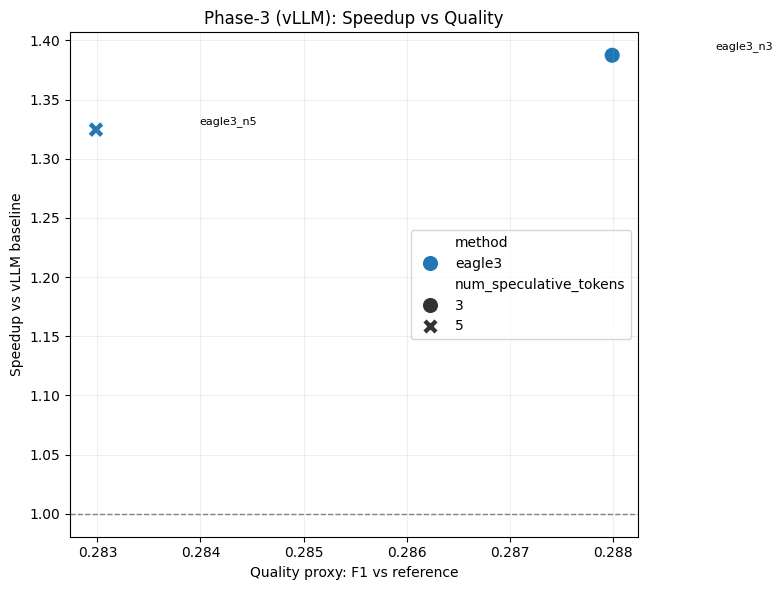

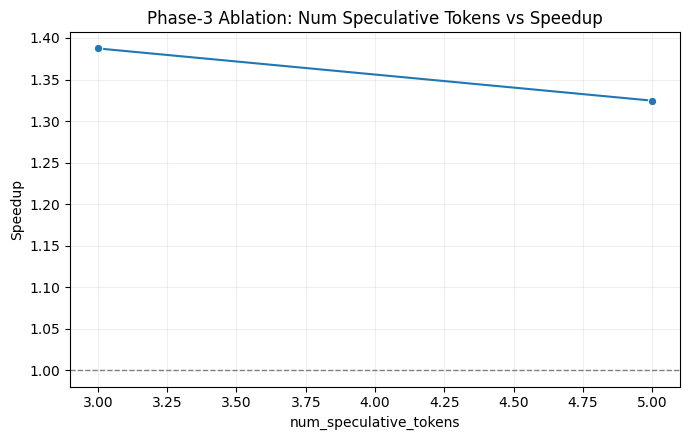

Phase-3 latency table by category:


,category,baseline_latency_s,best_spec_latency_s,speedup,best_config
0,math_reasoning,1.575138,1.078567,1.460399,eagle3_n3
1,summarization,1.626783,1.229279,1.323364,eagle3_n3



Saved Phase-3 artifacts:
- /content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2/phase3_vllm/phase3_speculative_results.csv
- /content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2/phase3_vllm/phase3_speculative_results.json
- /content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2/phase3_vllm/phase3_latency_by_category.csv
- /content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2/phase3_vllm/phase3_speedup_vs_quality.png
- /content/drive/MyDrive/LLM_Speculative_Decoding_Speed_Lab/spec_decoding_results_phase2/phase3_vllm/phase3_ablation_num_spec_tokens.png


In [16]:
# Study 2 | Step E - Final Plots and Exports
# Generate Study 2 figures/tables and write output artifacts.

from pathlib import Path

phase3_dir = Path(phase3_results_dir)
phase3_dir.mkdir(parents=True, exist_ok=True)

if "phase3_results_df" not in globals() or phase3_results_df is None or len(phase3_results_df) == 0:
    phase3_results_df = pd.read_csv(phase3_dir / "phase3_speculative_results.csv")

if "phase3_baseline_df" not in globals() or phase3_baseline_df is None or len(phase3_baseline_df) == 0:
    phase3_baseline_df = pd.read_json(phase3_dir / "phase3_baseline_outputs.jsonl", lines=True)

if "phase3_spec_runs" not in globals() or not phase3_spec_runs:
    phase3_spec_runs = {}
    for cfg in phase3_results_df["config"].tolist():
        cfg_path = phase3_dir / f"phase3_outputs_{cfg}.jsonl"
        if cfg_path.exists():
            phase3_spec_runs[cfg] = pd.read_json(cfg_path, lines=True)

# Main figure: Speedup vs Quality
plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    data=phase3_results_df,
    x="quality_f1_vs_reference",
    y="speedup",
    hue="method",
    style="num_speculative_tokens",
    s=140,
)
for _, r in phase3_results_df.iterrows():
    ax.text(r["quality_f1_vs_reference"] + 0.001, r["speedup"] + 0.005, r["config"], fontsize=8)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Phase-3 (vLLM): Speedup vs Quality")
ax.set_xlabel("Quality proxy: F1 vs reference")
ax.set_ylabel("Speedup vs vLLM baseline")
ax.grid(alpha=0.2)
plt.tight_layout()
phase3_main_fig = phase3_dir / "phase3_speedup_vs_quality.png"
plt.savefig(phase3_main_fig, dpi=180)
plt.show()

# Ablation: num_speculative_tokens
if len(phase3_results_df) > 1:
    plt.figure(figsize=(7, 4.5))
    sns.lineplot(data=phase3_results_df.sort_values("num_speculative_tokens"), x="num_speculative_tokens", y="speedup", marker="o")
    plt.axhline(1.0, color="gray", linestyle="--", linewidth=1)
    plt.title("Phase-3 Ablation: Num Speculative Tokens vs Speedup")
    plt.xlabel("num_speculative_tokens")
    plt.ylabel("Speedup")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    phase3_ablation_fig = phase3_dir / "phase3_ablation_num_spec_tokens.png"
    plt.savefig(phase3_ablation_fig, dpi=180)
    plt.show()

# Latency table by category for the best config
best_cfg = phase3_results_df.iloc[0]["config"]
best_df = phase3_spec_runs[best_cfg]

latency_rows = []
for cat in sorted(phase3_baseline_df["category"].unique()):
    b = phase3_baseline_df[phase3_baseline_df["category"] == cat]["latency_s"].mean()
    s = best_df[best_df["category"] == cat]["latency_s"].mean()
    latency_rows.append(
        {
            "category": cat,
            "baseline_latency_s": float(b),
            "best_spec_latency_s": float(s),
            "speedup": float(b / s) if s > 0 else 0.0,
            "best_config": best_cfg,
        }
    )

phase3_latency_table_df = pd.DataFrame(latency_rows).sort_values("speedup", ascending=False).reset_index(drop=True)
print("Phase-3 latency table by category:")
display(phase3_latency_table_df)

# Save artifacts
phase3_results_csv = phase3_dir / "phase3_speculative_results.csv"
phase3_results_json = phase3_dir / "phase3_speculative_results.json"
phase3_latency_csv = phase3_dir / "phase3_latency_by_category.csv"

phase3_results_df.to_csv(phase3_results_csv, index=False)
phase3_results_df.to_json(phase3_results_json, orient="records", indent=2)
phase3_latency_table_df.to_csv(phase3_latency_csv, index=False)

print("\nSaved Phase-3 artifacts:")
print("-", str(phase3_results_csv))
print("-", str(phase3_results_json))
print("-", str(phase3_latency_csv))
print("-", str(phase3_main_fig))
if len(phase3_results_df) > 1:
    print("-", str(phase3_ablation_fig))

